<a href="https://colab.research.google.com/github/LMariano418/LMariano418/blob/main/Profissao_Cientista_de_Dados_M17_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("/CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [3]:
#A) seu código aqui
df.info()

# Ajustando tipos se necessário
# Exemplo: transformar colunas categóricas
col_categoricas = df.select_dtypes(include='object').columns

for col in col_categoricas:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Age                 130 non-null    float64 
 1   Gender              164 non-null    category
 2   Income              164 non-null  

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [4]:
#seu código aqui
df.isnull().sum()

# Tratamento: preenchimento com mediana para numéricos
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# Tratamento: moda para categóricos
for col in df.select_dtypes(include='category').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()

/tmp/ipykernel_31227/4031617555.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_31227/4031617555.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,0
Age,0
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [5]:
#seu código aqui
for col in df.select_dtypes(include='category').columns:
    print(col)
    print(df[col].unique())
    print("------")

# Padronização (exemplo)
df = df.apply(lambda x: x.str.strip().str.lower() if x.dtype == "category" else x)

Gender
['Female', 'Male']
Categories (2, object): ['Female', 'Male']
------
Income
['50.000,00', '100.000,00', '75.000,00', '125.000,00', '150.000,00', ..., '102.500,00', '137.500,00', '127.500,00', '82.000,00', '68.000,00']
Length: 52
Categories (52, object): ['100.000,00', '102.500,00', '105.000,00', '110.000,00', ..., '90.000,00',
                          '92.500,00', '95.000,00', '97.500,00']
------
Education
['Bachelor's Degree', 'Master's Degree', 'Doctorate', 'High School Diploma', 'Associate's Degree']
Categories (5, object): ['Associate's Degree', 'Bachelor's Degree', 'Doctorate', 'High School Diploma',
                         'Master's Degree']
------
Marital Status
['Single', 'Married']
Categories (2, object): ['Married', 'Single']
------
Home Ownership
['Rented', 'Owned']
Categories (2, object): ['Owned', 'Rented']
------
Credit Score
['High', 'Average', 'Low']
Categories (3, object): ['Average', 'High', 'Low']
------


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

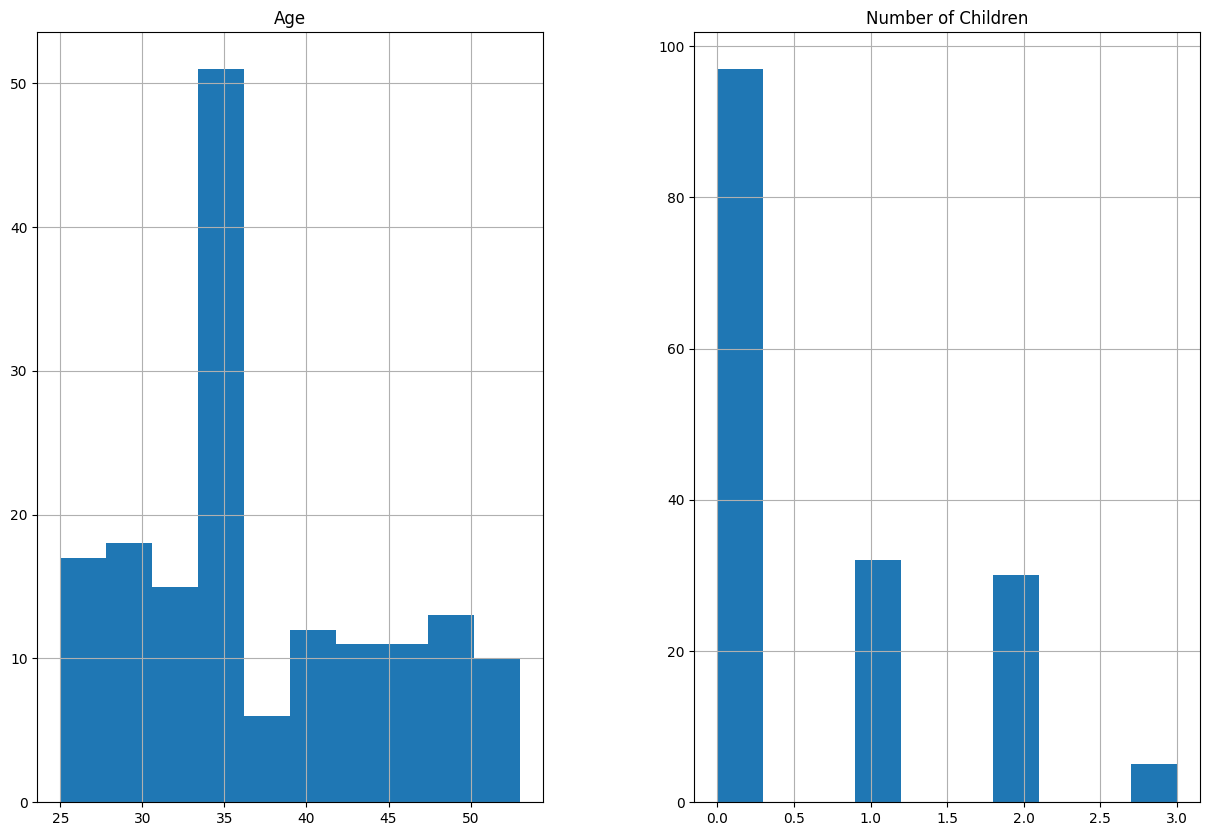

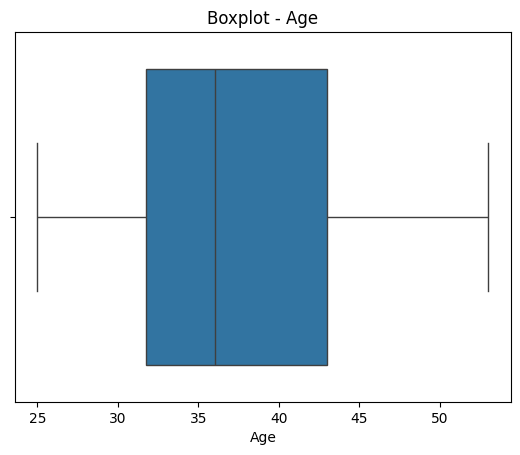

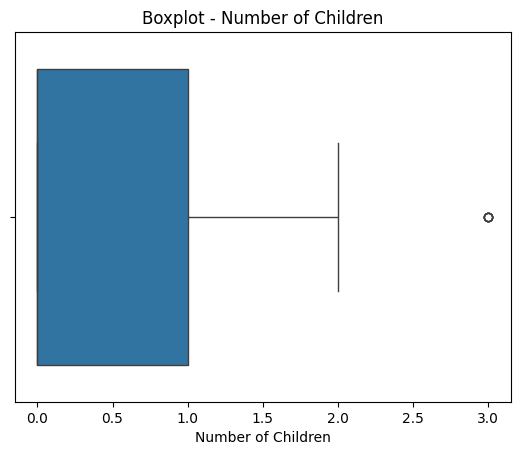

In [6]:
#seu código aqui
df.describe()

# Histogramas
df.hist(figsize=(15,10))
plt.show()

# Boxplot para outliers
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

In [7]:
#seu código aqui
for col in df.select_dtypes(include='category').columns:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribuição - {col}')
    plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [8]:
#seu código aqui
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



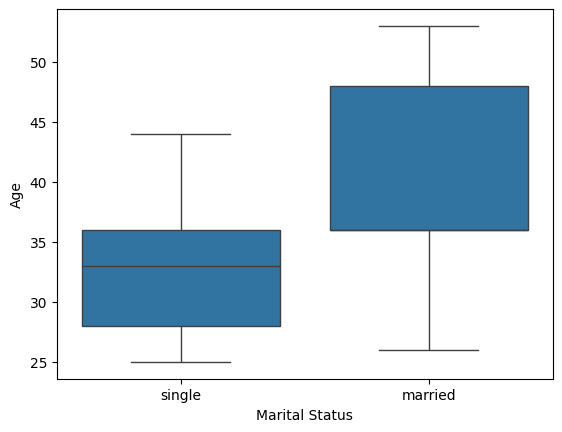

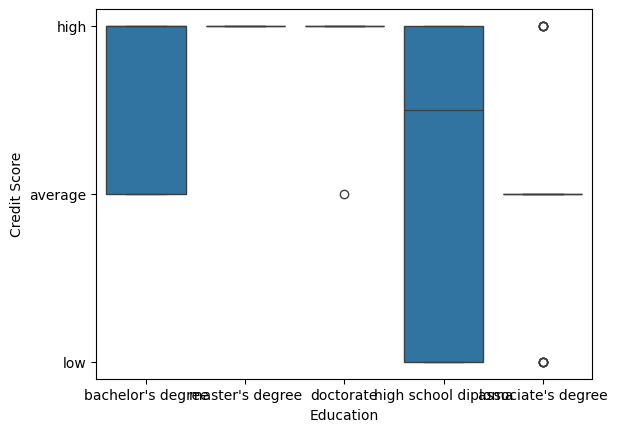

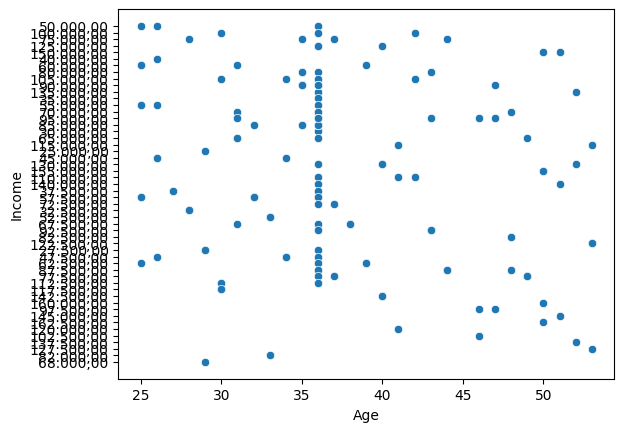

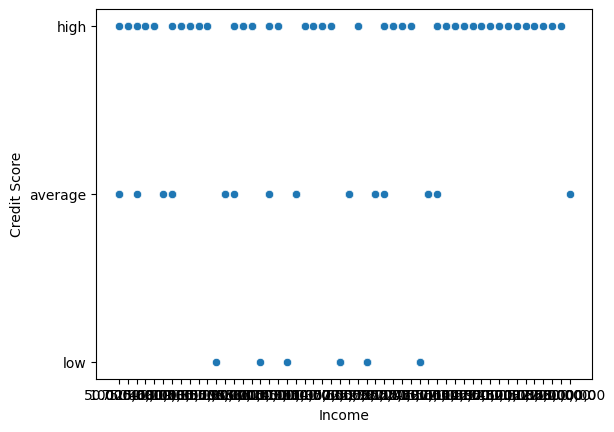

In [10]:
#seu código aqui
# Idade vs estado civil
sns.boxplot(x='Marital Status', y='Age', data=df)
plt.show()

# Score vs educação
sns.boxplot(x='Education', y='Credit Score', data=df)
plt.show()

# Salário vs idade
sns.scatterplot(x='Age', y='Income', data=df)
plt.show()

# Salário vs score
sns.scatterplot(x='Income', y='Credit Score', data=df)
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

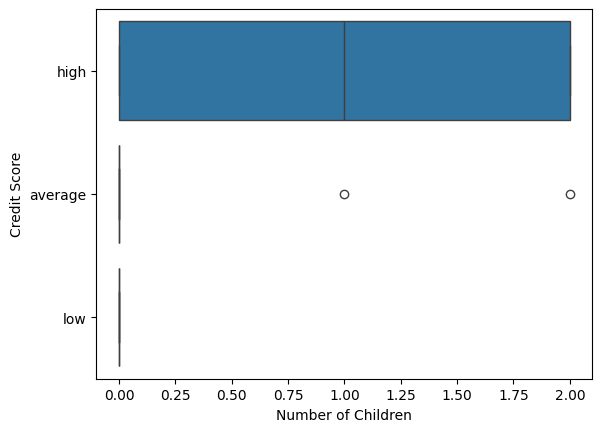

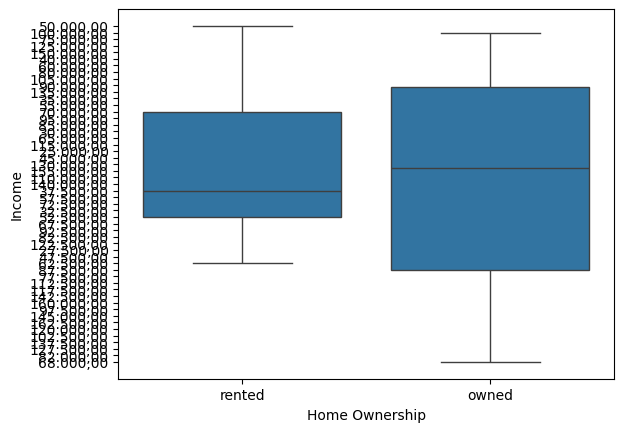

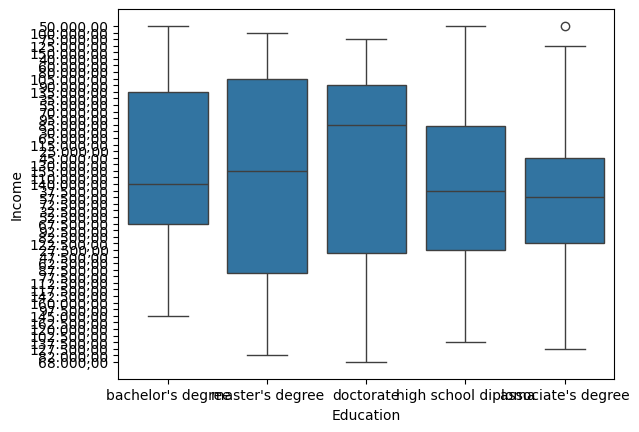

In [12]:
# seu código aqui
# 1: Filhos vs Score
sns.boxplot(x='Number of Children', y='Credit Score', data=df)
plt.show()

# 2: Casa vs renda
sns.boxplot(x='Home Ownership', y='Income', data=df)
plt.show()

# 3: Educação vs renda
sns.boxplot(x='Education', y='Income', data=df)
plt.show()

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

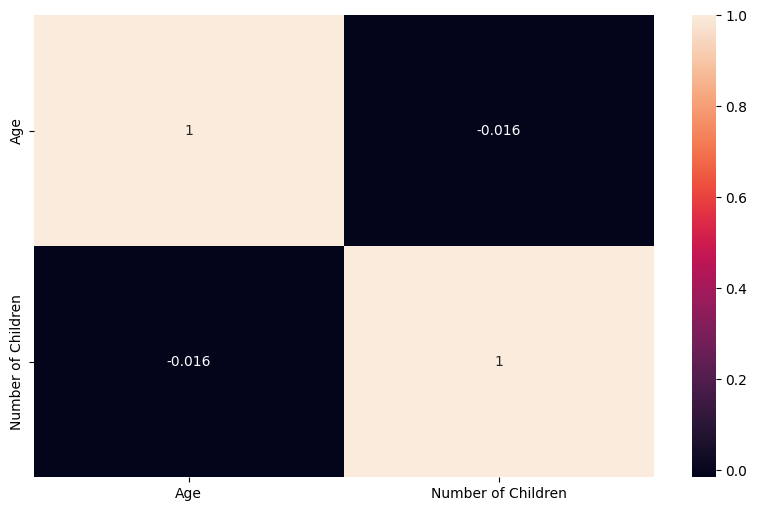

In [13]:
#seu código aqui
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [14]:
# sua justificativa aqui
# Variáveis como Income e Credit_Score tendem a ter correlação positiva,
# pois maior renda geralmente indica maior capacidade de pagamento.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [18]:
from sklearn.preprocessing import LabelEncoder

# 1. Convert 'Income' column to numeric
# It was made an object (string) in nQZpOg3cMMA7. Handle comma as decimal and dot as thousands separator.
df['Income'] = df['Income'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# 2. Apply LabelEncoder to other object type columns (which are now strings due to nQZpOg3cMMA7)
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Verify dtypes after transformations
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 159 non-null    float64
 1   Gender              159 non-null    int64  
 2   Income              159 non-null    float64
 3   Education           159 non-null    int64  
 4   Marital Status      159 non-null    int64  
 5   Number of Children  159 non-null    int64  
 6   Home Ownership      159 non-null    int64  
 7   Credit Score        159 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 11.2 KB


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

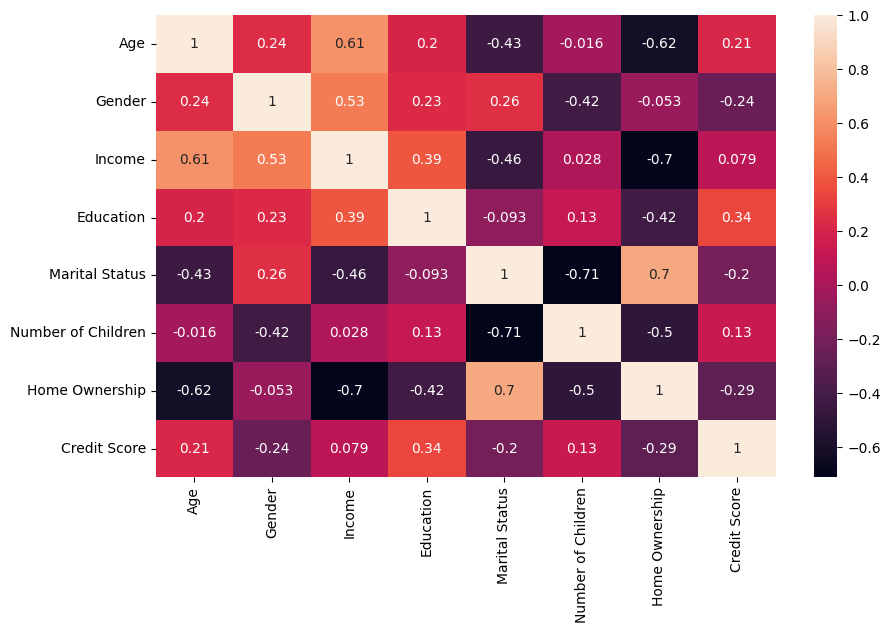

In [19]:
#seu código aqui
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [21]:
#seu código aqui
from sklearn.model_selection import train_test_split

X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape)
print(X_test.shape)

(127, 7)
(32, 7)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

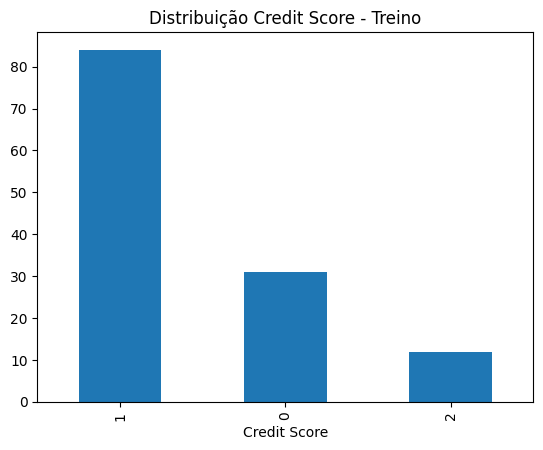

In [22]:
#seu código aqui
y_train.value_counts().plot(kind='bar')
plt.title("Distribuição Credit Score - Treino")
plt.show()

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [23]:
#seu código aqui
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(y_train_bal.value_counts())

Credit Score
1    84
0    84
2    84
Name: count, dtype: int64
